# Score-Based Diffusion Generating Model

## Setting

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

from src import config, layers, optimizer, sample, sde, toy_data, train
from tests import evaluation

## Variance-Preserving SDE

We consider a variance-preserving SDE given by 
$$
dX_t = -\frac12 \beta(t) X_t dt + \sqrt{\beta(t)} dW_t
$$
for $0\le t\le 1$, where $W_t$ is the standard Brownian motion with $W_0=0$ a.s. The schedule $\beta(t)$ is chosen so that $\beta(0)=\beta_1$, $\beta(1)=\beta_2$, $0<\beta_1<\beta_2$, increasing in $t$ and $B(t) := \int_0^t \beta(s)\, ds \to\infty$. 

We will use the following schedules for this project:
1. $\beta(t) = \beta_1 + (\beta_2 - \beta_1) t^k$ for $k>0$,
2. $\beta(t) = \frac{\pi}{1+a}\tan(\frac{\pi}{2}\frac{t+a}{1+a})$ for small enough $a>0$. In this case, $\beta_1 = \frac{\pi}{1+a}\tan(\frac{\pi}{2}\frac{a}{1+a})$ and $\beta_2=\infty$. (For this schedule, we use $k=0$ in the code.)

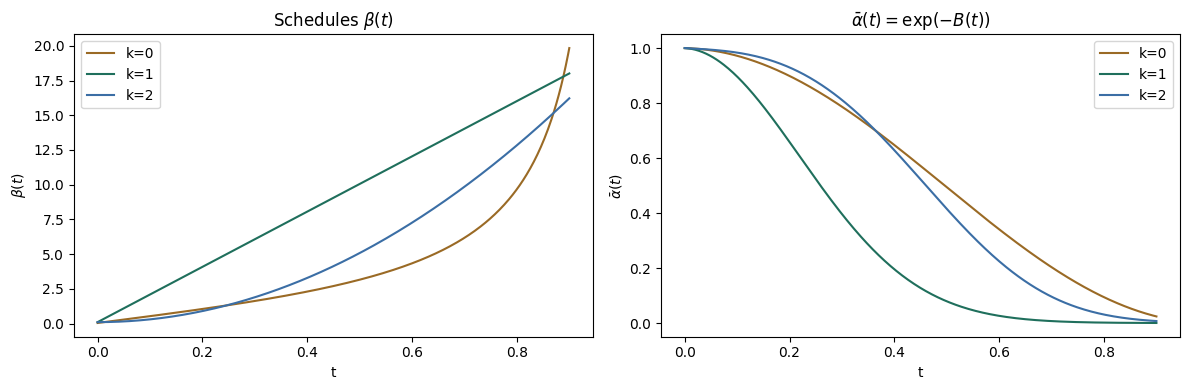

In [ ]:
ts = np.linspace(0.0, 0.9, 400)

ks = [0, 1, 2]

colors = {0: "#9a6a25", 1: "#1f6f5c", 2: "#3b6ea5"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for k in ks:
    vp_sde = sde.VPSDE(k)

    beta_vals = np.array([vp_sde.beta(float(t)) for t in ts])

    B_vals = np.array([vp_sde.beta_int(float(t)) for t in ts])

    alpha_bar = np.exp(-B_vals)

    axes[0].plot(ts, beta_vals, label=f"k={k}", color=colors[k])

    axes[1].plot(ts, alpha_bar, label=f"k={k}", color=colors[k])

axes[0].set_title(r"Schedules $\beta(t)$")
axes[0].set_xlabel("t")
axes[0].set_ylabel(r"$\beta(t)$")
axes[0].legend()

axes[1].set_title(r"$\bar\alpha(t) = \exp(-B(t))$")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$\bar\alpha(t)$")
axes[1].legend()


fig.tight_layout()
plt.show()

For the forward SDE $dX_t = -\frac12 \beta(t) X_t dt + \sqrt{\beta(t)} dW_t$ that we are dealitng with here, one can use the integrating factor technique with Ito's formula to obtain its solution 
$$
X_t = e^{-\frac12 \int_0^t \beta(s)\, ds} X_0 + \int_0^{t}\sqrt{\beta(s)}e^{-\frac12 \int_s^t \beta(u)\, du}\, dW_s.
$$
Let $\bar{\alpha}(t) = e^{- \int_0^t \beta(s)\, ds}$, then the stochastic integral term with respect to $W_s$ is indeed a centered Gaussian with the variance
$$
\mathrm{E}[\left(\int_0^{t}\sqrt{\beta(s)}e^{-\frac12 \int_s^t \beta(u)\, du}\, dW_s\right)^2] 
= \int_0^{t}\beta(s)e^{- \int_s^t \beta(u)\, du}\, d_s
= \sqrt{1-\bar{\alpha}(t)}.
$$
Therefore, $X_t \sim \sqrt{\bar{\alpha}(t)}X_0 + \sqrt{1-\bar{\alpha}(t)} Z$ where $Z\sim N(0,I)$ is independent of $X_0$.

Note that as $t\to\infty$ $\bar{\alpha}(t)$ goes to 0 for our chosen schedules $\beta$, which means that as $t\to\infty$, the distribution of $X_t$ gets close to the standard Gaussian. 

## Toy Data: Two Moons

For training and evaluation, we use the following dataset.

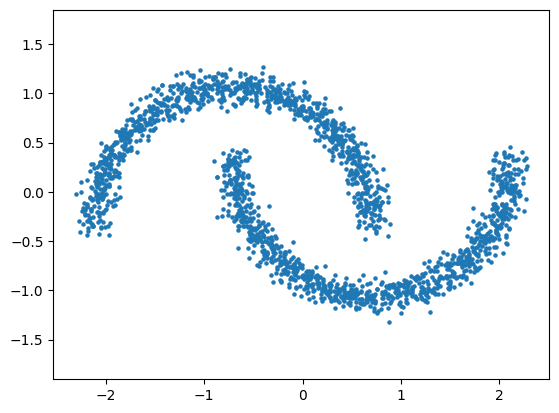

In [ ]:
dataset = toy_data.two_moons(2000)
plt.scatter(dataset[:, 0], dataset[:, 1], s=5)
plt.axis("equal")
plt.show()

This is a variation of two moons data.

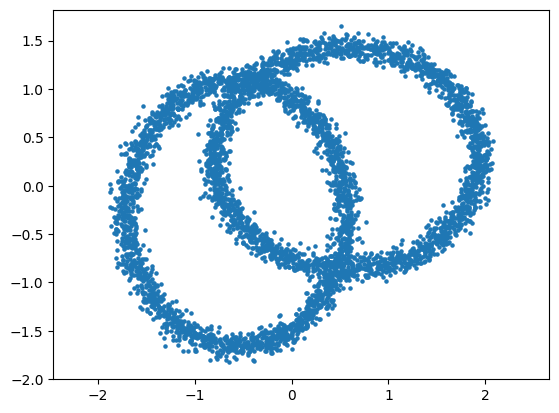

In [ ]:
dataset = toy_data.two_moons_full(5000)
plt.scatter(dataset[:, 0], dataset[:, 1], s=5)
plt.axis("equal")
plt.show()

From the two moons as an initial distribution, we add noise according to VP SDE, then we obtain the following pictures. The first is the case with linear schedule, the second is with the tangent schedule. 

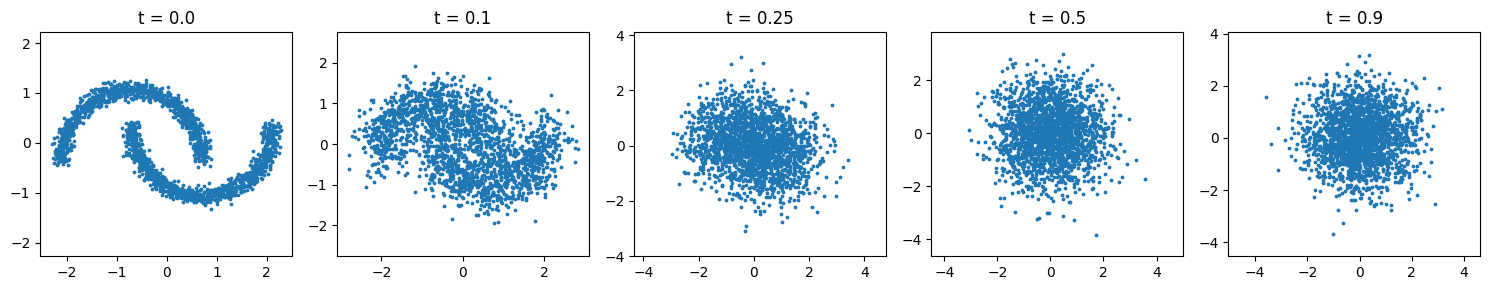

In [ ]:
xts = []
ts = [0.0, 0.1, 0.25, 0.5, 0.9]
vp_sde = sde.VPSDE(k=1)
rng = np.random.default_rng(42)

for t in ts:
    xt, _ = vp_sde.sample_marginal(dataset, t, rng)
    xts.append(xt)

fig, axes = plt.subplots(1, len(ts), figsize=(15, 3))

for ax, xt, t in zip(axes, xts, ts):
    ax.scatter(xt[:, 0], xt[:, 1], s=3)
    ax.set_title(f"t = {t}")
    ax.axis("equal")

plt.tight_layout()
plt.show()

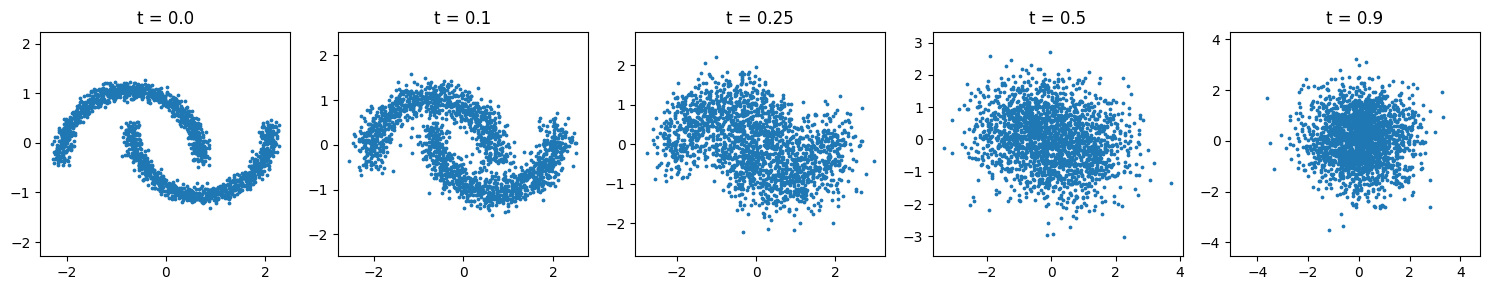

In [ ]:
xts = []
ts = [0.0, 0.1, 0.25, 0.5, 0.9]
vp_sde = sde.VPSDE(k=0)
rng = np.random.default_rng(42)

for t in ts:
    xt, _ = vp_sde.sample_marginal(dataset, t, rng)
    xts.append(xt)

fig, axes = plt.subplots(1, len(ts), figsize=(15, 3))

for ax, xt, t in zip(axes, xts, ts):
    ax.scatter(xt[:, 0], xt[:, 1], s=3)
    ax.set_title(f"t = {t}")
    ax.axis("equal")

plt.tight_layout()
plt.show()

## Reverse SDE and Score

For a general forward SDE $dX_t = f(X_t, t)\, dt + g(t)\, dW_t$, its time-reversal SDE is given by 
$$
dY_t = (f(Y_t,t)-g(t)^2 \nabla_x \log p_t(Y_t))\, dt + g(t) d\bar{W}_t.
$$
Here, $s(x,t) = \nabla_x \log p_t(x)$ is called the score. 

The goal of this project is to generate data using the variance-preserving diffusion process. If we know how to run this time-reversal process, then one can start with Gaussian random sampling and then we can rebuild the data by time-reverse process. 

It is however not tractable to figure out this time-reversal process due to the score. To figure out this unknown score, we will use a neural network. 

## Neural Network for Score Learning

For score learning, we will use a multilayer perceptron (MLP). Each layer is a linear transform and between layers there is an activation. For activation functions, we will use one of the following

- Rectifier Linear Unit (ReLU): the activation function $f(x)$ is given by $f(x) = \max{x,0}$. Its derivative is $f'(x) = 1$ if $x>0$ and otherwise 0.
- Sigmoid Linear Unit (SiLU): $f(x) = x \sigma(x)$ where $\sigma(x)=1/(1+e^{-x})$ is called the sigmoid. Its derivative is $f'(x) = x\sigma'(x) +\sigma(x)$.

For this project, we use 3 layers with hidden dimension 256. Our toy model is 2 dimensional but because our goal is to learn the score $s(x,t)$, the input dimension is 2+1. So, the first layer is a linear transform from $\mathrm{R}^3$ to $\mathrm{R}^{256}$. 

For backward propagation and optimization, one possible approach is to use MLE type loss function.

However, the problem along this line is that we don't know the probability density $p_t$. Instead, we use the conditional density instead. By Vincent (2011), we can use the denoising score-matching loss function. 

First, we learn a score function using ReLU and SGD. 

Training completed: 200000 iterations. Final batch loss = 0.6044


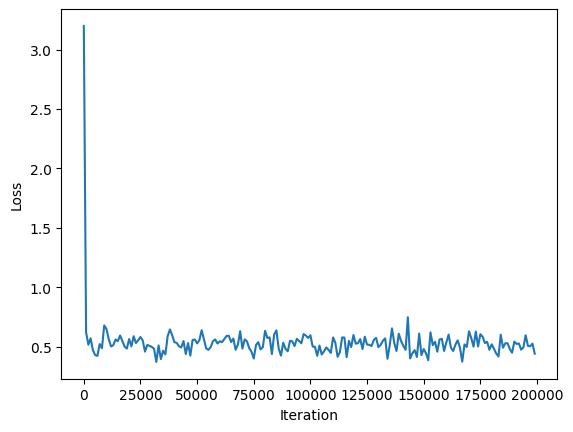

Model saved to ReLU_SGD


In [ ]:
model_1, loss_1 = train.train_model(
    config.NUM_ITERATIONS, 1, layers.ReLU, optimizer.SGD(1e-4)
)
train.save_model(model_1, "ReLU_SGD")

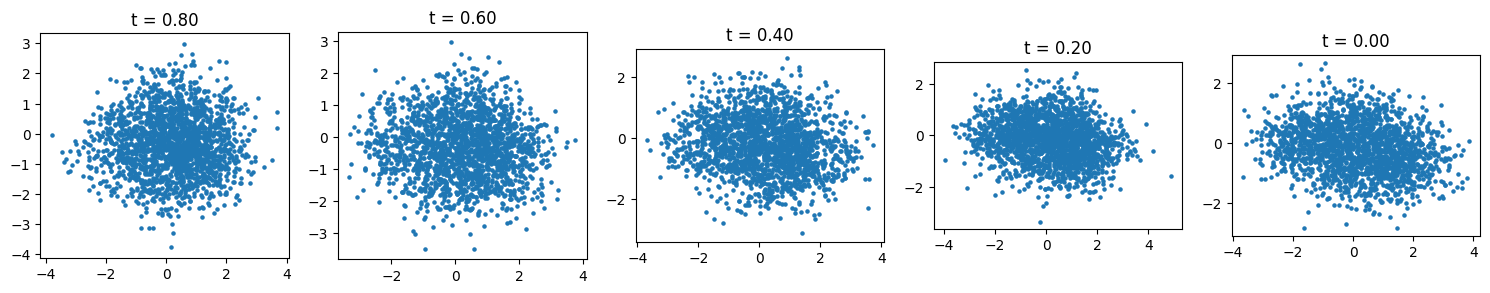

In [ ]:
sample_1 = sample.Sampler(model_file="ReLu_SGD.npz", schedule_type=1)
snapshot_times = [0.8, 0.6, 0.4, 0.2, 0.0]
snapshots = sample_1.sample(snapshot_times)
sample_1.plot_snapshots(snapshots)

Training completed: 200000 iterations. Final batch loss = 1.0991


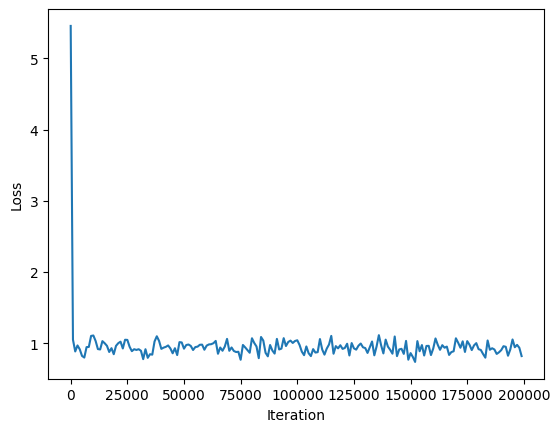

Model saved to ReLU_SGD_0


In [ ]:
model_2, loss_2 = train.train_model(
    config.NUM_ITERATIONS, 0, layers.ReLU, optimizer.SGD(1e-4)
)
train.save_model(model_2, "ReLU_SGD_0")

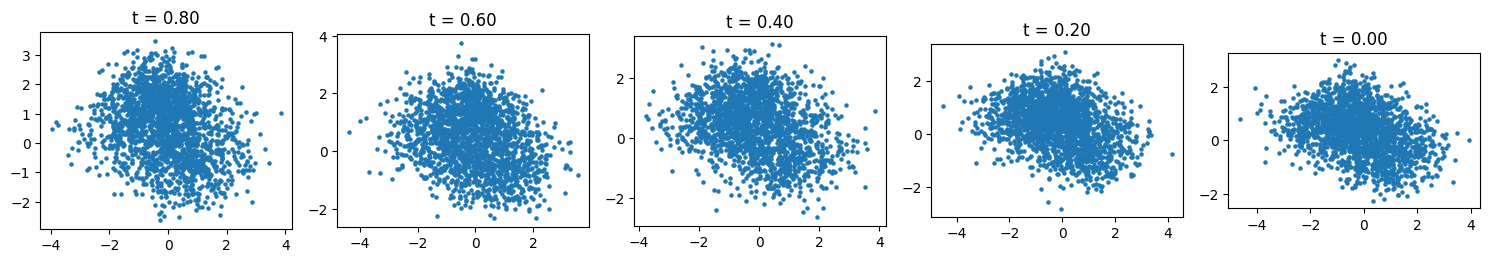

In [ ]:
sample_2 = sample.Sampler(model_file="ReLu_SGD_0.npz", schedule_type=0)
snapshots = sample_2.sample(snapshot_times)
sample_2.plot_snapshots(snapshots)

For both schedules (linear and tangent), the results are not satisfactory. Because the loss are oscillatory, the problem may stem from our choice of optimizer. SGD has a uniform learning rate. This might cause a problem when each dimension of input has a different scale. To resolve this, it would be reasonable to employ one of optimizers with moment method. We employ Adam here. 

Training completed: 200000 iterations. Final batch loss = 0.5116


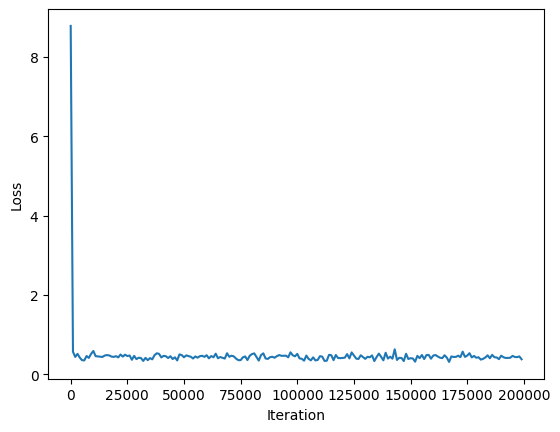

Model saved to ReLU_Adam_1


In [ ]:
model_3, loss_3 = train.train_model(
    config.NUM_ITERATIONS, 1, layers.ReLU, optimizer.Adam(1e-3)
)
train.save_model(model_3, "ReLU_Adam_1")

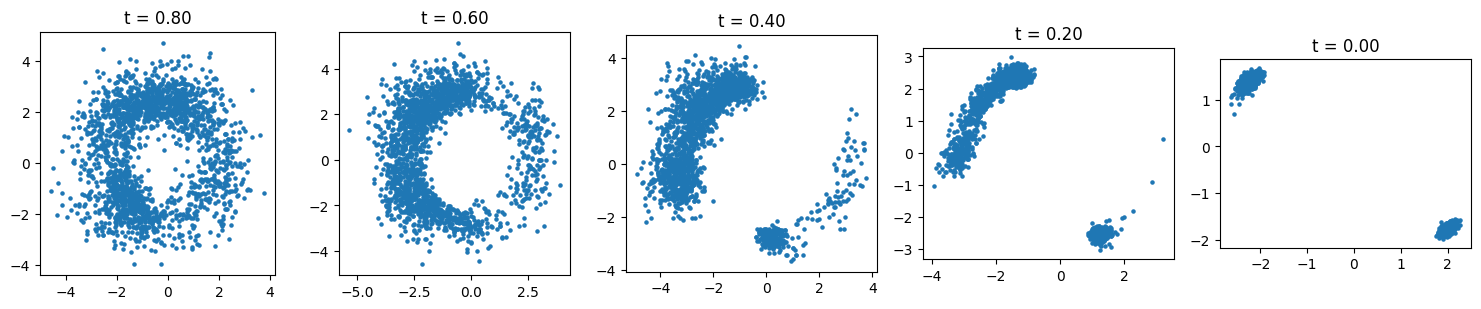

In [ ]:
sample_3 = sample.Sampler(model_file="ReLu_Adam_1.npz", schedule_type=1)
snapshots = sample_3.sample(snapshot_times)
sample_3.plot_snapshots(snapshots)

Training completed: 200000 iterations. Final batch loss = 0.9131


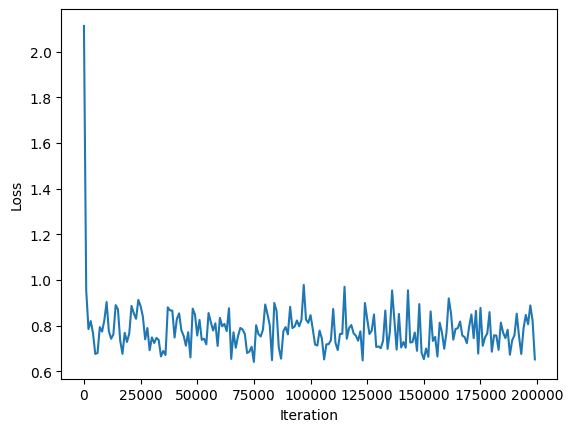

Model saved to ReLU_Adam_0


In [ ]:
model_4, loss_4 = train.train_model(
    config.NUM_ITERATIONS, 0, layers.ReLU, optimizer.Adam(1e-3)
)
train.save_model(model_4, "ReLU_Adam_0")

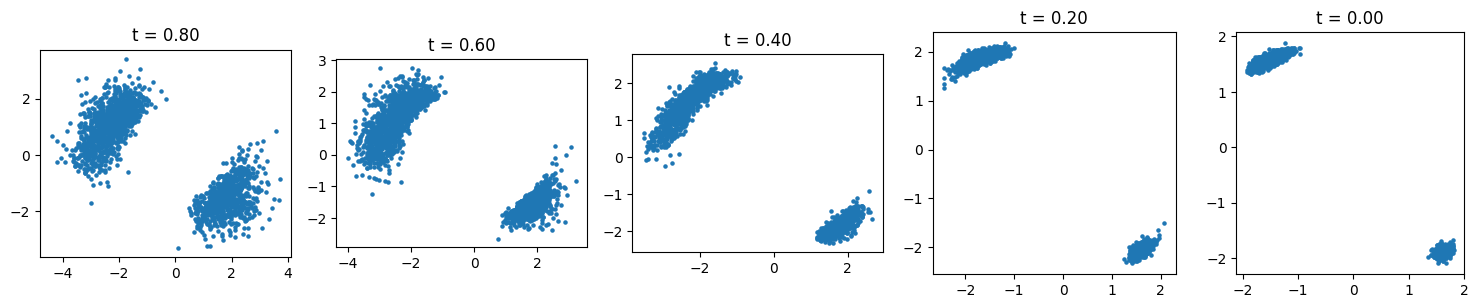

In [ ]:
sample_4 = sample.Sampler(model_file="ReLu_Adam_0.npz", schedule_type=0)
snapshots = sample_4.sample(snapshot_times)
sample_4.plot_snapshots(snapshots)

Stil, sampling results are not satisfactory. Another possible attempt to resolve this is to replace activation function. Currently, we employed ReLU, which is singular at 0. Instead, we use SiLu. One can also try GeLU here.

Training completed: 200000 iterations. Final batch loss = 0.5984


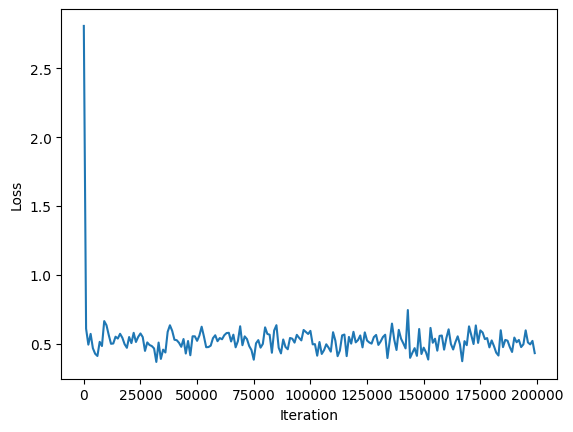

Model saved to SiLU_SGD_1


In [ ]:
model_5, loss_5 = train.train_model(
    config.NUM_ITERATIONS, 1, layers.SiLU, optimizer.SGD(1e-4)
)
train.save_model(model_5, "SiLU_SGD_1")

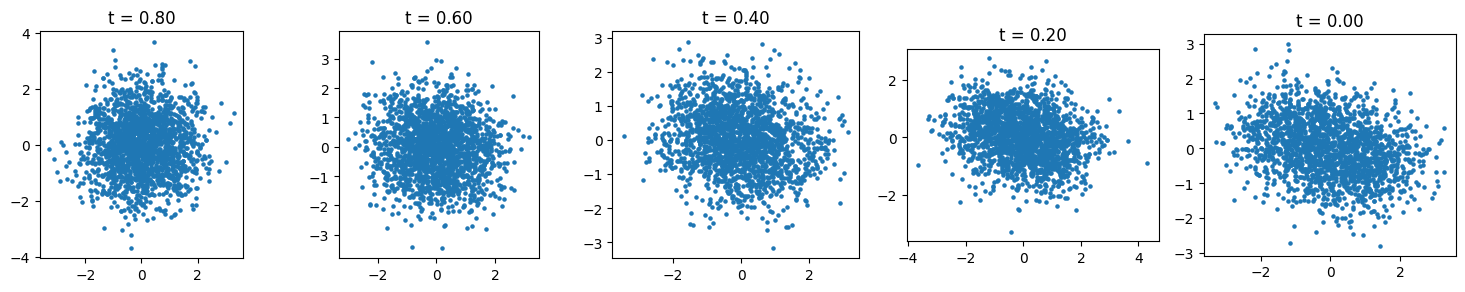

In [ ]:
sample_5 = sample.Sampler(model_file="SiLU_SGD_1.npz", schedule_type=1)
snapshots = sample_5.sample(snapshot_times)
sample_5.plot_snapshots(snapshots)

Training completed: 200000 iterations. Final batch loss = 1.0751


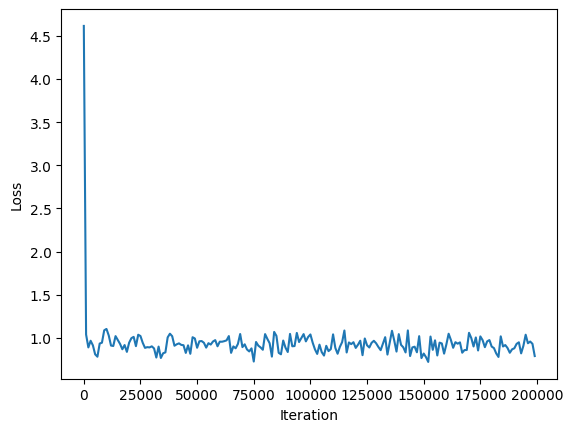

Model saved to SiLU_SGD_0


In [ ]:
model_6, loss_6 = train.train_model(
    config.NUM_ITERATIONS, 0, layers.SiLU, optimizer.SGD(1e-4)
)
train.save_model(model_6, "SiLU_SGD_0")

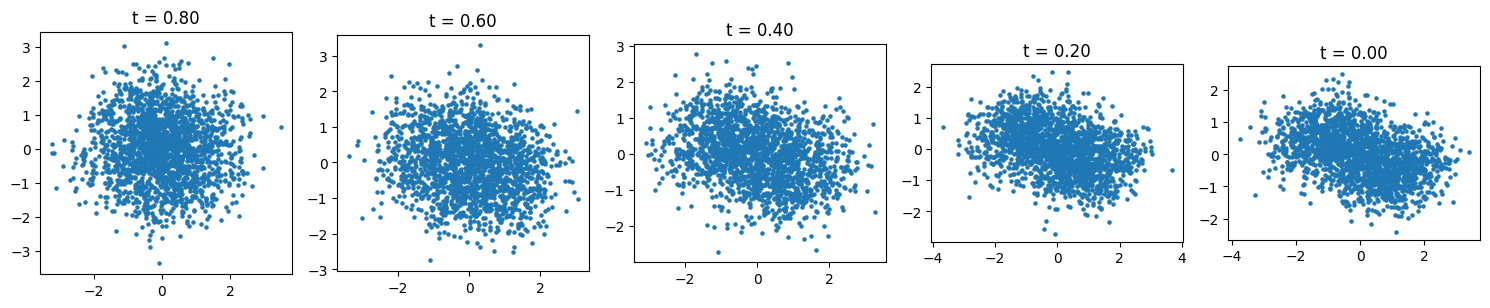

In [ ]:
sample_6 = sample.Sampler(model_file="SiLU_SGD_0.npz", schedule_type=0)
snapshots = sample_6.sample(snapshot_times)
sample_6.plot_snapshots(snapshots)

Training completed: 200000 iterations. Final batch loss = 0.5132


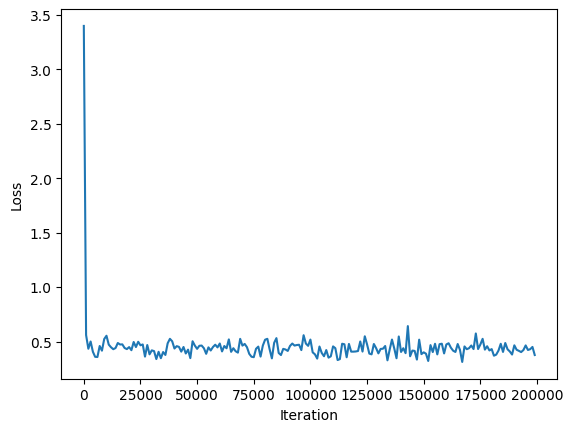

Model saved to SiLU_Adam_1


In [ ]:
model_7, loss_7 = train.train_model(
    config.NUM_ITERATIONS, 1, layers.SiLU, optimizer.Adam(1e-3)
)
train.save_model(model_7, "SiLU_Adam_1")

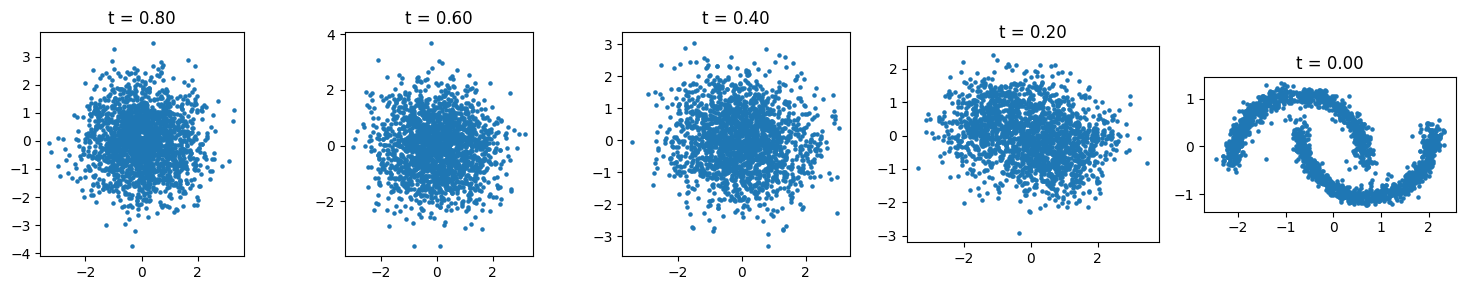

In [ ]:
sample_7 = sample.Sampler(model_file="SiLU_Adam_1.npz", schedule_type=1)
snapshots = sample_7.sample(snapshot_times)
sample_7.plot_snapshots(snapshots)

Training completed: 200000 iterations. Final batch loss = 0.9135


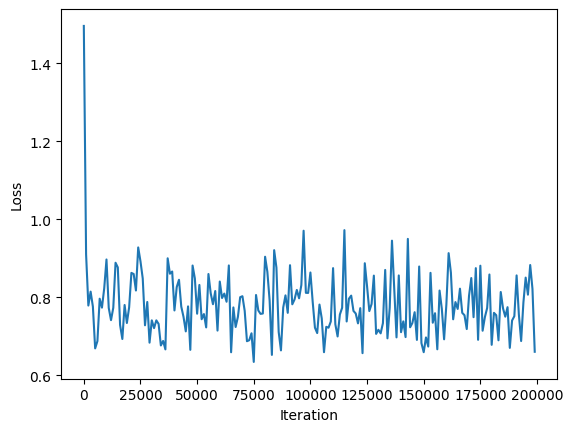

Model saved to SiLU_Adam_0


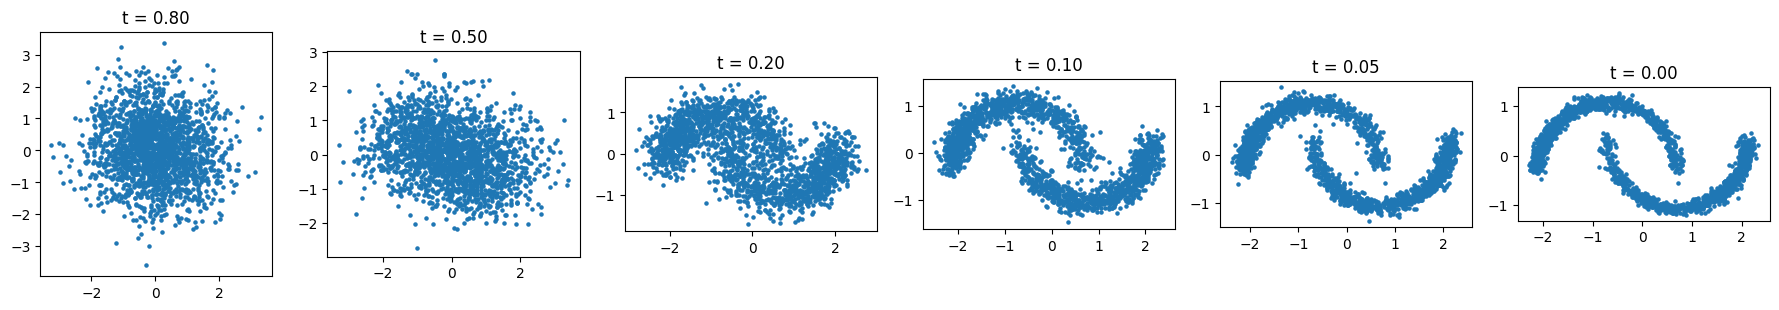

In [ ]:
model_8, loss_8 = train.train_model(
    config.NUM_ITERATIONS, 0, layers.SiLU, optimizer.Adam(1e-3)
)
train.save_model(model_8, "SiLU_Adam_0")

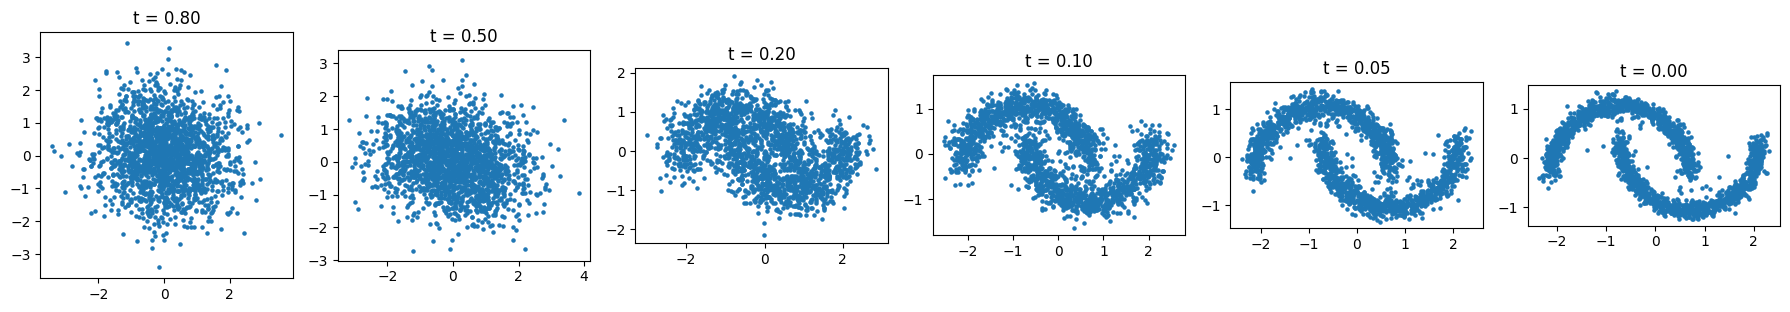

In [ ]:
snapshot_times = [0.8, 0.5, 0.2, 0.1, 0.05, 0.0]

sample_8 = sample.Sampler(model_file="SiLU_Adam_0.npz", schedule_type=0)
snapshots = sample_8.sample(snapshot_times)
sample_8.plot_snapshots(snapshots)

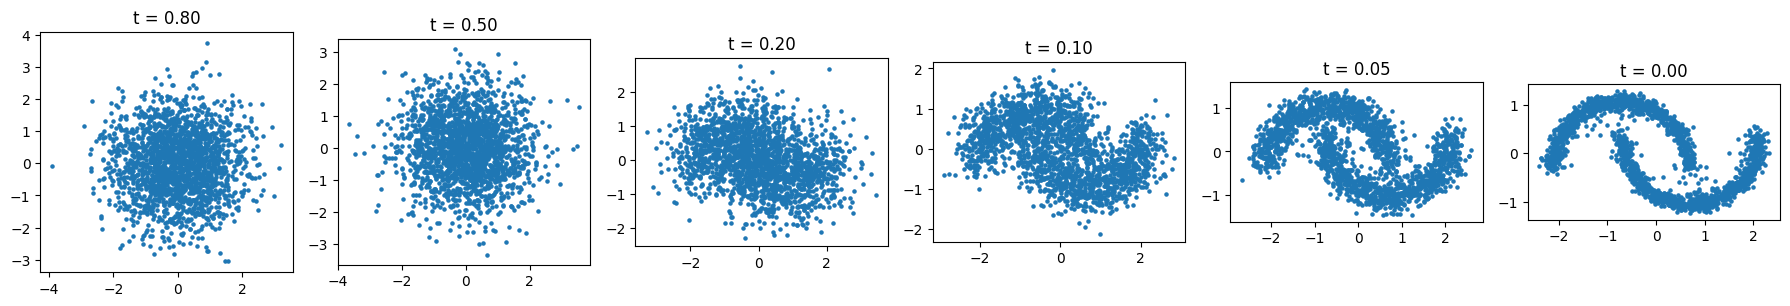

In [ ]:
snapshots = sample_7.sample(snapshot_times)
sample_7.plot_snapshots(snapshots)

Finally, SiLU with Adam produces the right picture. 

We test the model with a variant of two moons data.

Training completed: 200000 iterations. Final batch loss = 1.0330


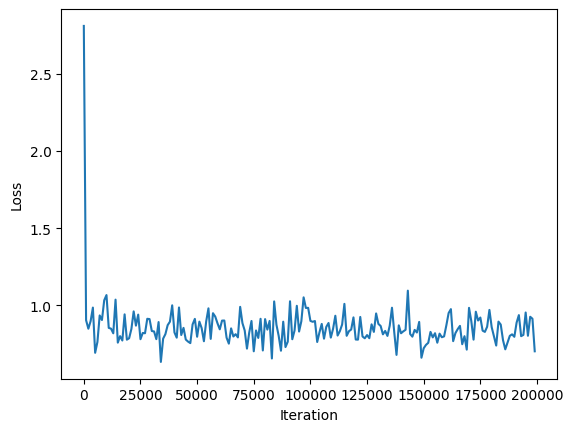

Model saved to SiLU_Adam_0_full


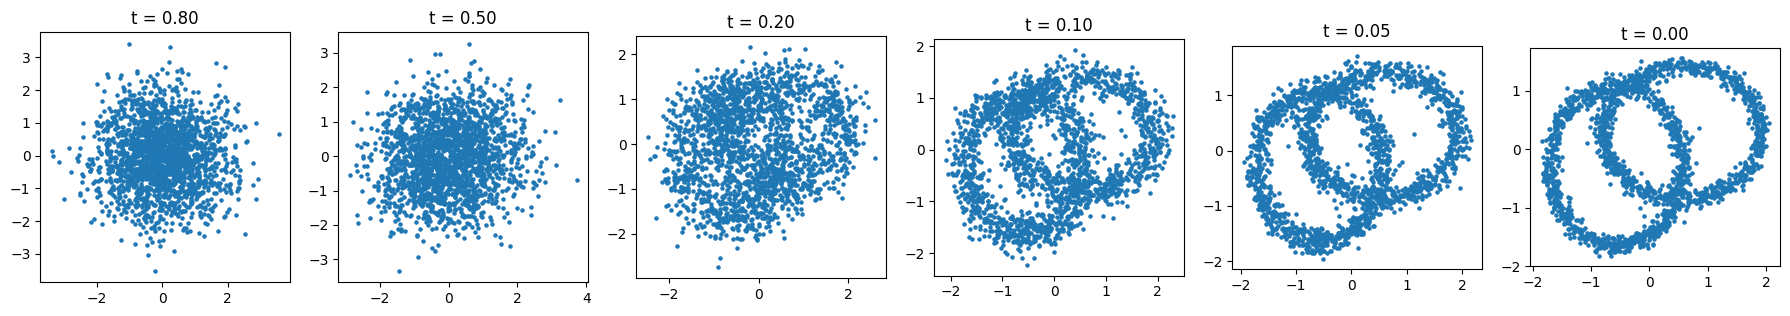

In [ ]:
model_9, loss_9 = train.train_model(
    config.NUM_ITERATIONS, 0, layers.SiLU, optimizer.Adam(1e-3)
)
train.save_model(model_9, "SiLU_Adam_0_full")
snapshot_times = [0.8, 0.5, 0.2, 0.1, 0.05, 0.0]

sample_9 = sample.Sampler(model_file="SiLU_Adam_0_full.npz", schedule_type=0)
snapshots = sample_9.sample(snapshot_times)
sample_9.plot_snapshots(snapshots)


## Evaluation

For evaluation, we employ 
- Wasserstein distance between sample and target distribution, and
- MSE for score functions.

First, load trained models for SiLU, Adam with linear and tangent schedules.


In [2]:
model_7 = train.load_model("SiLU_Adam_1.npz")
model_8 = train.load_model("SiLU_Adam_0.npz")

Model loaded from SiLU_Adam_1.npz
Model loaded from SiLU_Adam_0.npz


In [3]:
diffusion_7 = sde.VPSDE(k=1)
diffusion_8 = sde.VPSDE(k=0)

## Wasserstein distance

We sample from each trained models. 

In [4]:
sampler_7 = sample.Sampler(
    model=model_7,
    schedule_type=1,
)

sampler_8 = sample.Sampler(
    model=model_8,
    schedule_type=0,
)
snapshots_7 = sampler_7.sample([0.0])
snapshots_8 = sampler_8.sample([0.0])

generated_7 = snapshots_7[-1][1]
generated_8 = snapshots_8[-1][1]

Then, sample the target model (two moons). For Wasserstein distance, we use python library for optimal transport. 

In [ ]:
dataset = toy_data.two_moons_full(5000)

w2_7 = evaluation.WassersteinDistance(generated_7, dataset)
w2_8 = evaluation.WassersteinDistance(generated_8, dataset)

print(f"Model 7 W2: {w2_7:.4f}")
print(f"Model 8 W2: {w2_8:.4f}")

## MSE for Score functions

In [8]:
times = [0.1, 0.25, 0.5, 0.75, 0.9]

for t in times:
    rng = np.random.default_rng(42)

    xt_7, _ = diffusion_7.sample_marginal(dataset, t, rng)
    xt_8, _ = diffusion_8.sample_marginal(dataset, t, rng)

    mse_7 = evaluation.ScoreMSE(
        model_7,
        xt_7,
        t,
        diffusion_7,
        dataset,
    )

    mse_8 = evaluation.ScoreMSE(
        model_8,
        xt_8,
        t,
        diffusion_8,
        dataset,
    )

    print(f"t={t:.2f}: model_7={mse_7:.6f}, model_8={mse_8:.6f}")

t=0.10: model_7=22.913813, model_8=201.459352
t=0.25: model_7=0.484514, model_8=7.428222
t=0.50: model_7=0.006434, model_8=0.378071
t=0.75: model_7=0.000458, model_8=0.024877
t=0.90: model_7=0.000624, model_8=0.003514


In terms of W2 distance, the one with linear schedule looks slightly better than tangent schedule. However MSE for linear schedule is much smaller than that for tangent schedule. Thus, we conclude that under our setting (3 layers, 256 hidden dimensions, SiLU, Adam), linear schedule seems better than tangent schedule. 